# Optimal Transport Robust Linear Regression

## Goal

We want to compare an optimal transport (OT)-based robust regression method against:

1. Ordinary Least Squares (OLS)
2. Ridge regression
3. Lasso regression

We will test all methods under four scenarios:

1. clean data
2. noisy labels
3. outliers
4. distribution shift

We will report:

- MAE
- RMSE
- $R^2$
- training time

## Main idea

Instead of assuming the training data is exactly correct, OT-based robust training assumes that the data distribution may shift slightly inside an optimal transport neighborhood.

The model is then trained to perform well even under the worst nearby distribution.

This is different from ridge and lasso:
- ridge and lasso regularize the parameters directly
- OT-DRO performs robustness over nearby data distribution

# Mathematical setup

We consider linear regression with predictor $x \in \mathbb{R}^d$ and response $y \in \mathbb{R}$.

Our model is

$$
\hat{y} = x^\top \theta + b
$$

where:
- $\theta \in \mathbb{R}^d$ is the coefficient vector
- $b \in \mathbb{R}$ is the intercept

We define a transport cost on the predictors only.

$$
c(x,\tilde{x}) =
\begin{cases}
\psi(\|x-\tilde{x}\|_2 - \delta), & \text{if } \|x-\tilde{x}\|_2 > \delta \\
0, & \text{if } \|x-\tilde{x}\|_2 \le \delta
\end{cases}
$$

where:
- $\delta \ge 0$
- $\psi$ is non-decreasing
- $\psi(0)=0$

The response $y$ is not transported.

The OT-based distributionally robust optimization problem is

$$
\inf_{\theta} \sup_{Q : C(P_n,Q)\le \epsilon} \mathbb{E}_Q[\mathcal{L}_\theta]
$$

where:
- $P_n$ is the empirical training distribution
- $Q$ is any nearby distribution inside an OT ball of radius $\epsilon$
- $\mathcal{L}_\theta$ is the loss

# Dual reformulation

Using duality, the OT-DRO objective can be written as

$$
\inf_{\theta,\lambda>0}
\left\{
\lambda \epsilon + \mathbb{E}_{P_n}\left[\mathcal{L}^{c}_{\theta,\lambda}\right]
\right\}
$$

where the robustified loss is

$$
\mathcal{L}^{c}_{\theta,\lambda}(x,y)
=
\sup_{\Delta x \in \mathbb{R}^d}
\left\{
L\big(y - \theta^\top(x+\Delta x)\big)
-
\lambda \, \psi(\|\Delta x\|_2-\delta)\,\mathbf{1}_{\|\Delta x\|_2>\delta}
\right\}
$$

This looks hard because it is a $d$-dimensional maximization problem.

But there is an important simplification.

# Why the inner maximization becomes one-dimensional

Write the perturbation as

$$
\Delta x = \alpha \theta + \Delta x^\perp
$$

where

$$
\theta^\top \Delta x^\perp = 0
$$

Now notice:

$$
\theta^\top \Delta x = \alpha \|\theta\|_2^2
$$

So only the component of $\Delta x$ in the direction of $\theta$ affects the prediction.

The orthogonal component $\Delta x^\perp$ does not change the prediction, but it does increase the transport cost.

Therefore, the worst perturbation always lies in the direction of $\theta$.

This means the inner maximization reduces from a $d$-dimensional problem to a one-dimensional problem.

# Special case: $L(t)=|t|$

We now choose the loss

$$
L(t)=|t|
$$

For this case, the inner robustified loss simplifies to

$$
\mathcal{L}^{c}_{\theta,\lambda}(x,y)
=
|y-\theta^\top x|
+
\delta \|\theta\|_2
+
\lambda \psi^*\left(\frac{\|\theta\|_2}{\lambda}\right)
$$

where $\psi^*$ is the Legendre transform of $\psi$:

$$
\psi^*(u)=\sup_{s\ge0}\{su-\psi(s)\}
$$

Therefore the full optimization problem becomes

$$
\inf_{\theta,\lambda>0}
\left[
\frac{1}{n}\sum_{i=1}^n |y_i-\theta^\top x_i|
+
\delta \|\theta\|_2
+
\epsilon\lambda
+
\lambda\psi^*\left(\frac{\|\theta\|_2}{\lambda}\right)
\right]
$$

This is convex in $(\theta,\lambda)$.

# Choose a concrete transport penalty

We choose

$$
\psi(t)=\alpha t^2, \qquad \alpha>0
$$

Now compute the Legendre transform:

$$
\psi^*(u)=\sup_{s\ge0}\left\{su-\alpha s^2\right\}
$$

Take derivative with respect to $s$:

$$
u-2\alpha s = 0
$$

so the maximizer is

$$
s^*=\frac{u}{2\alpha}
$$

Plug it back in:

$$
\psi^*(u)
=
u\cdot\frac{u}{2\alpha}
-
\alpha\left(\frac{u}{2\alpha}\right)^2
$$

$$
=
\frac{u^2}{2\alpha}
-
\frac{u^2}{4\alpha}
=
\frac{u^2}{4\alpha}
$$

Therefore,

$$
\psi^*(u)=\frac{u^2}{4\alpha}
$$

# Final OT-DRO objective

Substitute $\psi^*(u)=u^2/(4\alpha)$ into the objective:

$$
J(\theta,\lambda)
=
\frac{1}{n}\sum_{i=1}^n |y_i-\theta^\top x_i|
+
\delta\|\theta\|_2
+
\epsilon\lambda
+
\lambda\cdot
\frac{\left(\|\theta\|_2/\lambda\right)^2}{4\alpha}
$$

So,

$$
J(\theta,\lambda)
=
\frac{1}{n}\sum_{i=1}^n |y_i-\theta^\top x_i|
+
\delta\|\theta\|_2
+
\epsilon\lambda
+
\frac{\|\theta\|_2^2}{4\alpha\lambda}
$$

Now minimize over $\lambda>0$.

For fixed $\theta$, we minimize

$$
\epsilon\lambda + \frac{\|\theta\|_2^2}{4\alpha\lambda}
$$

Using the identity

$$
\min_{\lambda>0}\left(a\lambda+\frac{b}{\lambda}\right)=2\sqrt{ab}
$$

we get

$$
2\sqrt{
\epsilon\cdot \frac{\|\theta\|_2^2}{4\alpha}
}
=
\|\theta\|_2\sqrt{\frac{\epsilon}{\alpha}}
$$

Therefore the problem reduces to

$$
J(\theta)
=
\frac{1}{n}\sum_{i=1}^n |y_i-\theta^\top x_i|
+
\left(\delta+\sqrt{\frac{\epsilon}{\alpha}}\right)\|\theta\|_2
$$

Define

$$
\kappa=\delta+\sqrt{\frac{\epsilon}{\alpha}}
$$

Then the final model is

$$
J(\theta)
=
\frac{1}{n}\sum_{i=1}^n |y_i-\theta^\top x_i|
+
\kappa\|\theta\|_2
$$

In practice, we also include an intercept $b$ and do not penalize it:

$$
J(\theta,b)
=
\frac{1}{n}\sum_{i=1}^n |y_i-(x_i^\top\theta+b)|
+
\kappa\|\theta\|_2
$$

# Practical interpretation

Our OT-DRO estimator is:

- an $L^1$ data-fit term, which is robust to outliers
- an $L^2$ penalty on the coefficients
- derived from distributional robustness, not from standard parameter regularization alone

We will compare this model against:
- OLS
- Ridge
- Lasso

In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Synthetic data generation

We generate data from a known linear model:

$$
y = X\theta^* + b^* + \eta
$$

where:
- $X$ is the feature matrix
- $\theta^*$ is the true coefficient vector
- $b^*$ is the true intercept
- $\eta$ is Gaussian noise

In [4]:
def generate_linear_data(n=600, d=20, noise_std=1.0, seed=42, sparse=False):
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, size=(n, d))

    if sparse:
        beta_true = np.zeros(d)
        idx = rng.choice(d, size=max(3, d // 5), replace=False)
        beta_true[idx] = rng.normal(0, 3, size=len(idx))
    else:
        beta_true = rng.normal(0, 2, size=d)

    intercept_true = 1.5
    y = X @ beta_true + intercept_true + rng.normal(0, noise_std, size=n)

    return X, y, beta_true, intercept_true

In [25]:
X, y, beta_true, intercept_true = generate_linear_data()
print(X)
print(beta_true)

[[ 0.30471708 -1.03998411  0.7504512  ... -0.9588826   0.8784503
  -0.04992591]
 [-0.18486236 -0.68092954  1.22254134 ... -0.84015648 -0.82448122
   0.65059279]
 [ 0.74325417  0.54315427 -0.66550971 ...  1.49494131 -0.86583112
   0.96827835]
 ...
 [ 0.7509563   0.52396481  1.88264902 ... -0.46276538  2.86226358
   0.15582507]
 [-0.59639205 -1.37830174  1.3054062  ...  0.75378082 -1.78652796
  -1.7807522 ]
 [ 0.91827612  1.52012282 -1.26520004 ...  0.83747681 -0.93342254
  -1.3973866 ]]
[-0.61957513  0.12047235 -2.48151189 -2.77550712  0.36459556 -1.51556113
 -2.90502343  1.93068258 -1.26358935  2.29962321  0.05694158  0.58951772
 -0.42299949 -5.31032449 -2.27357298 -0.25141892  0.72945827 -3.57934804
 -0.10720342 -2.24452817]


# Corruption settings

We test four scenarios:

1. clean data
2. noisy labels
3. outliers
4. distribution shift

These are implemented below.

In [5]:
def add_label_noise(y, noise_std=5.0, seed=0):
    rng = np.random.default_rng(seed)
    return y + rng.normal(0, noise_std, size=len(y))

def add_outliers(X, y, outlier_frac=0.1, y_scale=25.0, x_scale=8.0, seed=0):
    rng = np.random.default_rng(seed)
    X_new = X.copy()
    y_new = y.copy()

    n = len(y)
    m = int(outlier_frac * n)
    idx = rng.choice(n, size=m, replace=False)

    X_new[idx] += rng.normal(0, x_scale, size=X_new[idx].shape)
    y_new[idx] += rng.normal(0, y_scale, size=m)

    return X_new, y_new

def apply_distribution_shift(X, mean_shift=1.0, scale_shift=1.5): #hard shift
    return X * scale_shift + mean_shift

# Data splitting and standardization

We split the data into:
- training set
- validation set
- test set

We standardize the features using the training set only.

In [6]:
def split_and_scale(X_train, X_val, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_val_scaled, X_test_scaled, scaler

# Baseline models

We implement:
- OLS
- Ridge
- Lasso

Ridge and lasso are tuned using the validation set.

In [7]:
def fit_ols(X_train, y_train):
    model = LinearRegression()
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0
    return model, elapsed

def fit_ridge_tuned(X_train, y_train, X_val, y_val, alphas):
    best_model = None
    best_alpha = None
    best_mae = np.inf
    t0 = time.perf_counter()

    for alpha in alphas:
        model = Ridge(alpha=alpha)
        model.fit(X_train, y_train)
        pred = model.predict(X_val)
        mae = mean_absolute_error(y_val, pred)

        if mae < best_mae:
            best_mae = mae
            best_alpha = alpha
            best_model = model

    elapsed = time.perf_counter() - t0
    return best_model, best_alpha, elapsed

def fit_lasso_tuned(X_train, y_train, X_val, y_val, alphas):
    best_model = None
    best_alpha = None
    best_mae = np.inf
    t0 = time.perf_counter()

    for alpha in alphas:
        model = Lasso(alpha=alpha, max_iter=10000)
        model.fit(X_train, y_train)
        pred = model.predict(X_val)
        mae = mean_absolute_error(y_val, pred)

        if mae < best_mae:
            best_mae = mae
            best_alpha = alpha
            best_model = model

    elapsed = time.perf_counter() - t0
    return best_model, best_alpha, elapsed

# OT-DRO model implementation

We implement the estimator

$$
\min_{\theta,b}
\frac{1}{n}\sum_{i=1}^n |y_i-(x_i^\top\theta+b)|
+
\kappa\|\theta\|_2
$$

This is convex, so we solve it with CVXPY.

In [12]:
import cvxpy as cp

class OTDRORegressor:
    def __init__(self, kappa=1.0):
        self.kappa = kappa
        self.beta_ = None
        self.intercept_ = None
        self.solve_time_ = None

    def fit(self, X, y):
        n, d = X.shape

        beta = cp.Variable(d)
        b = cp.Variable()

        residuals = y - (X @ beta + b)

        objective = cp.Minimize((1 / n) * cp.norm1(residuals) + self.kappa * cp.norm(beta, 2))
        problem = cp.Problem(objective)

        t0 = time.perf_counter()
        problem.solve(solver=cp.SCS, verbose=False)
        self.solve_time_ = time.perf_counter() - t0

        self.beta_ = beta.value
        self.intercept_ = b.value
        return self

    def predict(self, X):
        return X @ self.beta_ + self.intercept_

# Tuning the robustness parameter

Instead of tuning $\delta$, $\epsilon$, and $\alpha$ separately, we tune the effective parameter

$$
\kappa = \delta + \sqrt{\frac{\epsilon}{\alpha}}
$$

using the validation set.

In [13]:
def fit_otdro_tuned(X_train, y_train, X_val, y_val, kappas):
    best_model = None
    best_kappa = None
    best_mae = np.inf
    t0 = time.perf_counter()

    for kappa in kappas:
        model = OTDRORegressor(kappa=kappa)
        model.fit(X_train, y_train)
        pred = model.predict(X_val)
        mae = mean_absolute_error(y_val, pred)

        if mae < best_mae:
            best_mae = mae
            best_kappa = kappa
            best_model = model

    elapsed = time.perf_counter() - t0
    return best_model, best_kappa, elapsed

# Evaluation metrics

We measure:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- $R^2$
- training time

In [14]:
def evaluate_model(model, X_test, y_test, model_name, train_time):
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "train_time_sec": train_time
    }

# Full experiment pipeline

This function:
- generates synthetic data
- applies one corruption setting
- splits the data
- standardizes the features
- tunes each model
- evaluates on the test set

In [15]:
def run_experiment(setting="clean", seed=42):
    X, y, beta_true, intercept_true = generate_linear_data(
        n=600, d=20, noise_std=1.0, seed=seed, sparse=False
    )

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.25, random_state=seed
    )

    if setting == "clean":
        pass
    elif setting == "noise":
        y_train = add_label_noise(y_train, noise_std=5.0, seed=seed)
    elif setting == "outliers":
        X_train, y_train = add_outliers(
            X_train, y_train, outlier_frac=0.1, y_scale=25.0, x_scale=8.0, seed=seed
        )
    elif setting == "shift":
        X_test = apply_distribution_shift(X_test, mean_shift=1.0, scale_shift=1.5)
    else:
        raise ValueError("Unknown setting")

    X_train_scaled, X_val_scaled, X_test_scaled, scaler = split_and_scale(X_train, X_val, X_test)

    ridge_alphas = np.logspace(-3, 2, 10)
    lasso_alphas = np.logspace(-3, 1, 10)
    kappas = np.logspace(-3, 1, 10)

    ols_model, ols_time = fit_ols(X_train_scaled, y_train)
    ridge_model, ridge_alpha, ridge_time = fit_ridge_tuned(
        X_train_scaled, y_train, X_val_scaled, y_val, ridge_alphas
    )
    lasso_model, lasso_alpha, lasso_time = fit_lasso_tuned(
        X_train_scaled, y_train, X_val_scaled, y_val, lasso_alphas
    )
    otdro_model, best_kappa, otdro_time = fit_otdro_tuned(
        X_train_scaled, y_train, X_val_scaled, y_val, kappas
    )

    results = []
    results.append(evaluate_model(ols_model, X_test_scaled, y_test, "OLS", ols_time))
    results.append(evaluate_model(ridge_model, X_test_scaled, y_test, f"Ridge(alpha={ridge_alpha:.4f})", ridge_time))
    results.append(evaluate_model(lasso_model, X_test_scaled, y_test, f"Lasso(alpha={lasso_alpha:.4f})", lasso_time))
    results.append(evaluate_model(otdro_model, X_test_scaled, y_test, f"OT-DRO(kappa={best_kappa:.4f})", otdro_time))

    return pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)

# Run one experiment in each setting

In [16]:
settings = ["clean", "noise", "outliers", "shift"]

all_results = {}
for s in settings:
    print(f"Running setting: {s}")
    all_results[s] = run_experiment(setting=s, seed=42)
    display(all_results[s])

Running setting: clean


,model,MAE,RMSE,R2,train_time_sec
0,Lasso(alpha=0.0010),0.775794,0.976192,0.989038,0.014648
1,Ridge(alpha=0.0010),0.776886,0.977263,0.989013,0.015238
2,OLS,0.776891,0.977266,0.989013,0.008269
3,OT-DRO(kappa=0.0599),0.784394,0.974058,0.989085,1.161411


Running setting: noise


,model,MAE,RMSE,R2,train_time_sec
0,Lasso(alpha=0.0215),0.986194,1.240254,0.982305,0.007193
1,Ridge(alpha=2.1544),0.993151,1.248414,0.982071,0.008362
2,OLS,1.005167,1.259266,0.981758,0.000699
3,OT-DRO(kappa=0.0599),1.276343,1.599575,0.970566,0.599518


Running setting: outliers


,model,MAE,RMSE,R2,train_time_sec
0,OT-DRO(kappa=0.0010),3.917528,4.897281,0.724102,0.605416
1,OLS,6.891367,8.365123,0.195023,0.000594
2,Ridge(alpha=0.0010),6.891374,8.365131,0.195021,0.007461
3,Lasso(alpha=0.0010),6.892503,8.366426,0.194772,0.008295


Running setting: shift


,model,MAE,RMSE,R2,train_time_sec
0,OT-DRO(kappa=0.0599),18.659681,19.293029,-3.281931,1.155842
1,Lasso(alpha=0.0010),18.666273,19.306711,-3.288007,0.006881
2,Ridge(alpha=0.0010),18.672031,19.313651,-3.291090,0.009902
3,OLS,18.672079,19.313708,-3.291116,0.000608


# What these results say

The results show that the OT-DRO method is most useful when the data contains strong outliers, but it is not consistently the best method in every setting.

For the clean-data experiment, all four models performed very similarly. Lasso had the best MAE, while OT-DRO had a slightly better RMSE and $R^2$. However, these differences were very small, so the main takeaway is that on clean data, all methods were essentially comparable in predictive performance. The biggest difference was computational cost: OT-DRO was much slower than OLS, ridge, and lasso.

For the noisy-label experiment, lasso performed best overall, followed closely by ridge and OLS. OT-DRO performed noticeably worse in MAE, RMSE, and $R^2$. This suggests that for ordinary label noise, classical regularized linear models may be more effective than the OT-DRO model used here.

For the outlier experiment, OT-DRO clearly outperformed all other methods by a large margin. Its MAE and RMSE were much lower, and its $R^2$ was substantially higher than OLS, ridge, and lasso. This is the strongest result in the study and supports the main motivation of the method: OT-based robust training is especially effective when the training data is contaminated by extreme or corrupted samples.

For the distribution-shift experiment, OT-DRO achieved the best numerical values among the four methods, but the improvement was very small. More importantly, all models had strongly negative $R^2$ values, which means that every method performed poorly under this shift setting. Therefore, the correct conclusion is not that OT-DRO solved distribution shift, but rather that under this particular and severe shift, all methods struggled, with OT-DRO showing only a slight edge.

In terms of training time, OLS was the fastest, ridge and lasso were also very efficient, and OT-DRO was consistently much slower. This means there is a clear practical trade-off: OT-DRO can provide strong robustness to outliers, but it comes at a significantly higher computational cost.

Overall, these experiments suggest that the main advantage of OT-DRO is robustness to outliers. On clean data, its performance is comparable to the classical methods but not clearly better. Under ordinary noise, it is weaker than ridge and lasso. Under severe distribution shift, it only shows a very small improvement while all methods still fail. Therefore, the strongest and most defensible conclusion is that OT-DRO is particularly valuable in settings where outlier robustness is the main concern.

# Repeat over multiple random seeds

For a more reliable comparison, we repeat each experiment over several random seeds and report mean and standard deviation.

In [17]:
def run_repeated_experiments(setting="clean", seeds=(1, 2, 3, 4, 5)):
    frames = []
    for seed in seeds:
        df = run_experiment(setting=setting, seed=seed)
        df["seed"] = seed
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

def summarize_results(combined_df):
    numeric_cols = ["MAE", "RMSE", "R2", "train_time_sec"]
    return combined_df.groupby("model")[numeric_cols].agg(["mean", "std"])

In [18]:
repeated_results = {}
summaries = {}

for s in settings:
    print(f"Repeating setting: {s}")
    repeated_results[s] = run_repeated_experiments(setting=s, seeds=(1, 2, 3, 4, 5))
    summaries[s] = summarize_results(repeated_results[s])
    display(summaries[s])

Repeating setting: clean


MAE                RMSE                  R2           train_time_sec          
                          mean       std      mean       std      mean       std           mean       std
model                                                                                                    
Lasso(alpha=0.0010)   0.851354       NaN  1.061800       NaN  0.983530       NaN       0.007740       NaN
Lasso(alpha=0.0077)   0.848670  0.014516  1.014460  0.018553  0.987302  0.001213       0.008754  0.000601
Lasso(alpha=0.0215)   0.848950       NaN  1.058049       NaN  0.987591       NaN       0.006895       NaN
Lasso(alpha=0.0599)   0.799826       NaN  1.036930       NaN  0.991273       NaN       0.007499       NaN
OLS                   0.832218  0.037467  1.029041  0.031090  0.987528  0.003058       0.000658  0.000132
OT-DRO(kappa=0.0010)  0.874001  0.011683  1.045624  0.003067  0.986529  0.000717       0.752984  0.081340
OT-DRO(kappa=0.0599)  0.812269  0.076046  1.041667  0.064071  0.987342  0.006507       0.787835  0.013413
OT-DRO(kappa=0.1668)  0.861892       NaN  1.062156       NaN  0.987494       NaN       0.825778       NaN
Ridge(alpha=0.0010)   0.844686       NaN  1.005505       NaN  0.988061       NaN       0.009184       NaN
Ridge(alpha=0.1668)   0.851177       NaN  1.061566       NaN  0.983538       NaN       0.008991       NaN
Ridge(alpha=2.1544)   0.804168  0.052819  1.026213  0.040465  0.989795  0.003010       0.007838  0.000711
Ridge(alpha=7.7426)   0.851073       NaN  1.023367       NaN  0.986555       NaN       0.007897       NaN

Repeating setting: noise


MAE                RMSE                  R2           train_time_sec          
                          mean       std      mean       std      mean       std           mean       std
model                                                                                                    
Lasso(alpha=0.0010)   1.196896       NaN  1.487407       NaN  0.967681       NaN       0.007950       NaN
Lasso(alpha=0.0077)   1.227450  0.113969  1.496223  0.139671  0.977055  0.010035       0.007232  0.000920
Lasso(alpha=0.0599)   1.254581  0.095996  1.588156  0.086094  0.969616  0.006403       0.006676  0.000150
OLS                   1.240031  0.103391  1.542022  0.122738  0.971698  0.008331       0.000626  0.000089
OT-DRO(kappa=0.0077)  1.451300  0.100796  1.767297  0.105606  0.959041  0.001264       0.884377  0.066632
OT-DRO(kappa=0.0215)  1.401700       NaN  1.812984       NaN  0.973323       NaN       0.508600       NaN
OT-DRO(kappa=0.1668)  1.600932  0.180477  1.998410  0.239701  0.951292  0.016447       0.667564  0.182554
Ridge(alpha=0.5995)   1.141658       NaN  1.393254       NaN  0.984245       NaN       0.007584       NaN
Ridge(alpha=2.1544)   1.190701       NaN  1.480379       NaN  0.967986       NaN       0.009171       NaN
Ridge(alpha=27.8256)  1.231162       NaN  1.562285       NaN  0.968665       NaN       0.007495       NaN
Ridge(alpha=7.7426)   1.209043  0.079141  1.534450  0.035184  0.973013  0.002441       0.007960  0.000468

Repeating setting: outliers


MAE                RMSE                  R2           train_time_sec          
                          mean       std      mean       std      mean       std           mean       std
model                                                                                                    
Lasso(alpha=0.0010)   6.542181  1.351326  8.104898  1.720831  0.323076  0.125289       0.011438  0.006978
Lasso(alpha=0.0077)   6.599426       NaN  8.102423       NaN  0.224772       NaN       0.008530       NaN
Lasso(alpha=0.0599)   5.813798       NaN  7.031615       NaN  0.277716       NaN       0.008168       NaN
OLS                   6.411278  1.008915  7.893341  1.304290  0.293570  0.099023       0.000717  0.000145
OT-DRO(kappa=0.0010)  2.183573  0.610967  2.710975  0.758763  0.906154  0.044682       0.793067  0.181240
OT-DRO(kappa=0.0028)  5.340220       NaN  6.718321       NaN  0.633675       NaN       0.606851       NaN
Ridge(alpha=0.0010)   6.555315  1.104041  8.103050  1.405368  0.298711  0.113568       0.009033  0.001355
Ridge(alpha=7.7426)   5.825712       NaN  7.044021       NaN  0.275165       NaN       0.009294       NaN

Repeating setting: shift


MAE                 RMSE                  R2           train_time_sec          
                           mean       std       mean       std      mean       std           mean       std
model                                                                                                      
Lasso(alpha=0.0010)   13.331007       NaN  13.988230       NaN -1.858403       NaN       0.007648       NaN
Lasso(alpha=0.0077)    9.602387  7.426911  10.461009  7.294939 -0.620933  1.781818       0.006646  0.000201
Lasso(alpha=0.0215)    4.307820       NaN   5.130613       NaN  0.708209       NaN       0.006821       NaN
Lasso(alpha=0.0599)    9.168061       NaN  10.306563       NaN  0.137869       NaN       0.007274       NaN
OLS                    9.296094  4.888654  10.188746  4.810266 -0.471335  1.306731       0.000598  0.000047
OT-DRO(kappa=0.0010)   9.723429  7.454968  10.604768  7.319893 -0.659544  1.811850       0.800288  0.147534
OT-DRO(kappa=0.0599)  11.571363  3.014637  12.479054  2.643016 -0.960487  1.480424       0.824682  0.036939
OT-DRO(kappa=0.1668)   4.099980       NaN   4.894016       NaN  0.734500       NaN       0.971648       NaN
Ridge(alpha=0.0010)   14.882652       NaN  15.658592       NaN -1.895377       NaN       0.007304       NaN
Ridge(alpha=0.1668)   13.328205       NaN  13.985374       NaN -1.857236       NaN       0.008091       NaN
Ridge(alpha=2.1544)    6.855541  3.571189   7.867444  3.833853  0.398525  0.433783       0.007916  0.001083
Ridge(alpha=7.7426)    4.170783       NaN   5.083244       NaN  0.668265       NaN       0.007068       NaN

# Plot the results

In [20]:
def plot_metric_across_settings(summaries, metric="MAE"):
    rows = []

    for setting, summary in summaries.items():
        for model in summary.index:
            rows.append({
                "setting": setting,
                "model": model,
                "mean": summary.loc[model, (metric, "mean")],
                "std": summary.loc[model, (metric, "std")]
            })

    plot_df = pd.DataFrame(rows)

    for setting in ["clean", "noise", "outliers", "shift"]:
        subset = plot_df[plot_df["setting"] == setting]

        plt.figure(figsize=(8, 4))
        plt.bar(subset["model"], subset["mean"], yerr=subset["std"], capsize=4)
        plt.xticks(rotation=25, ha="right")
        plt.ylabel(metric)
        plt.title(f"{metric} comparison under {setting}")
        plt.tight_layout()
        plt.show()

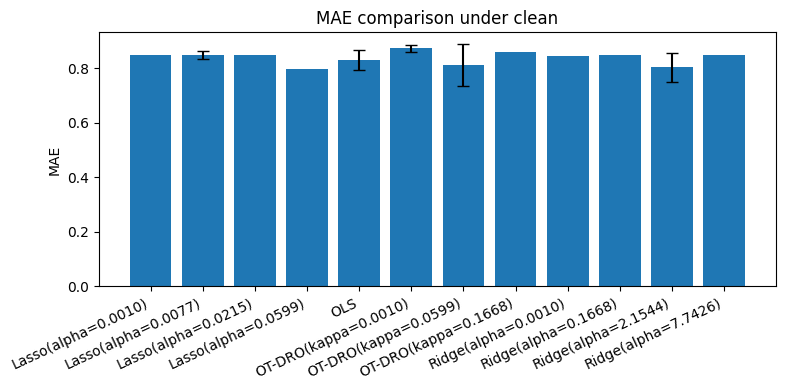

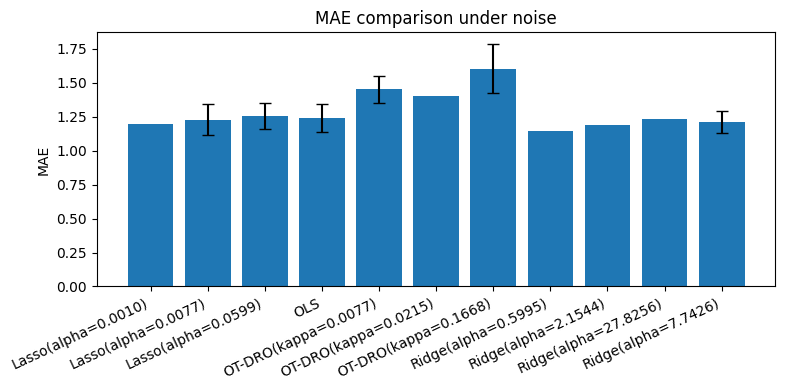

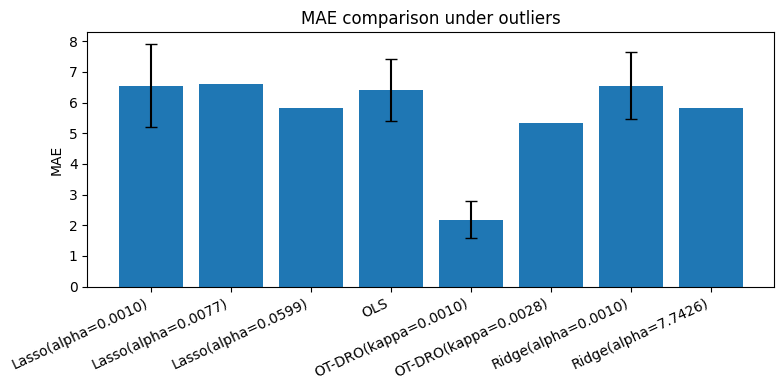

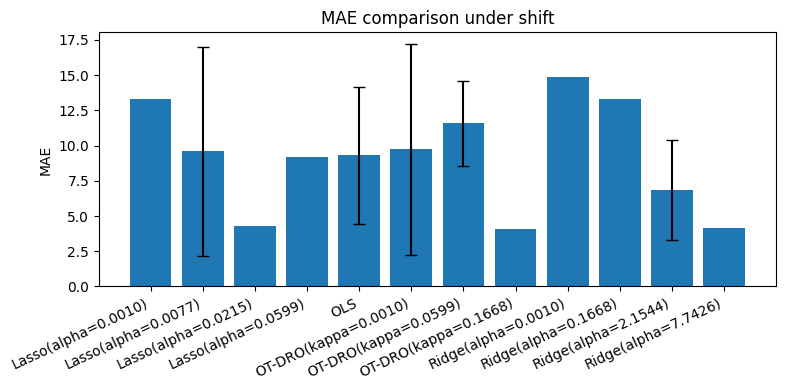

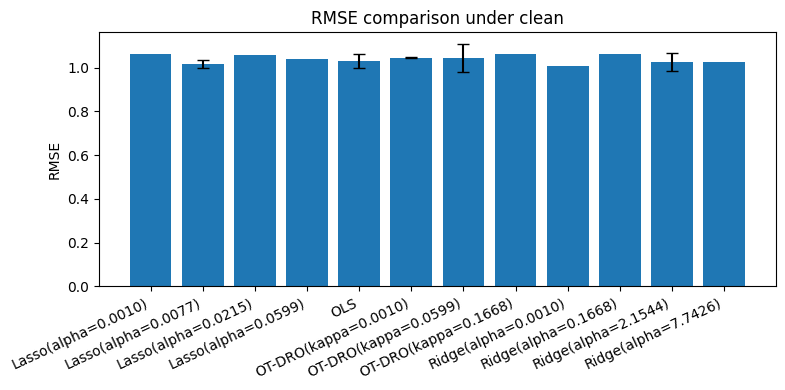

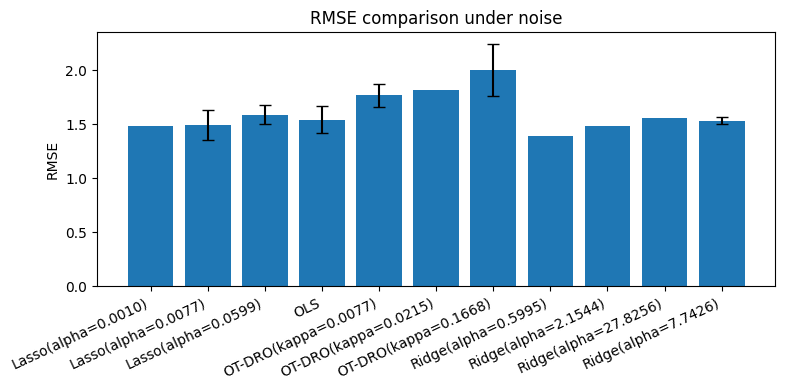

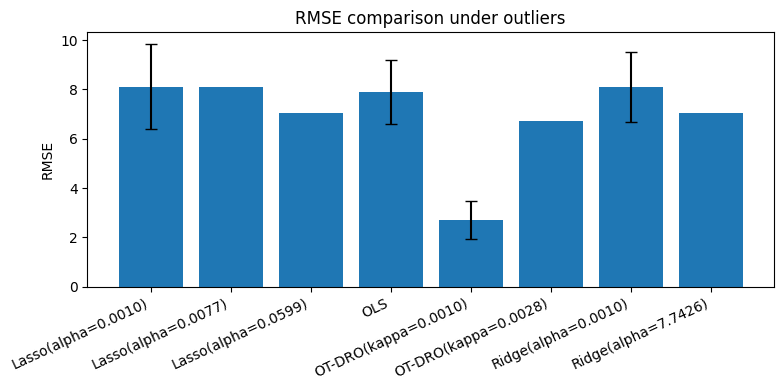

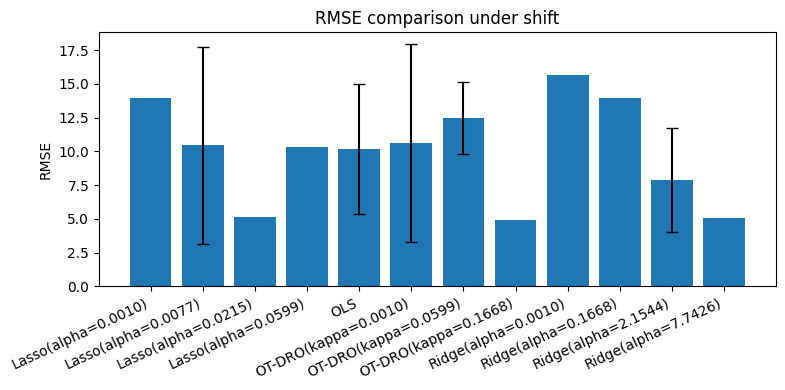

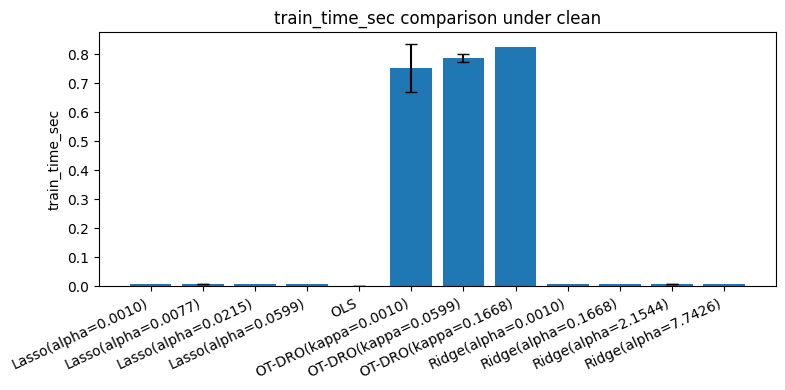

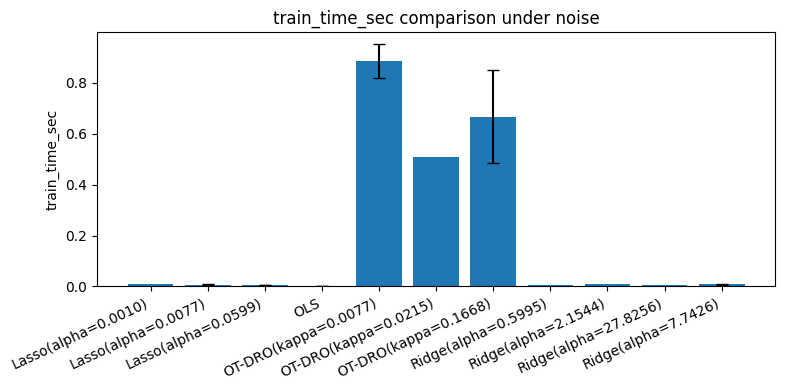

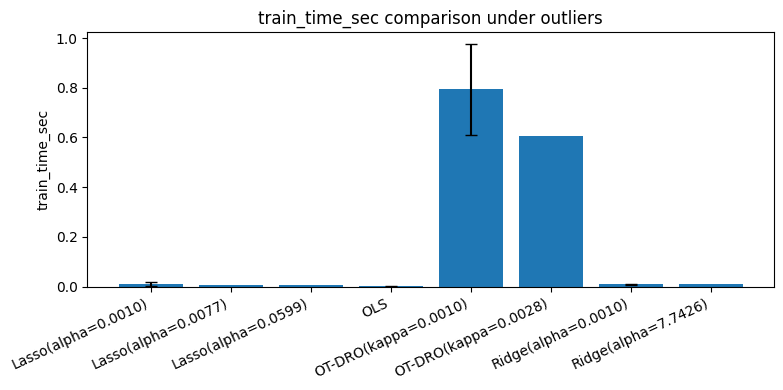

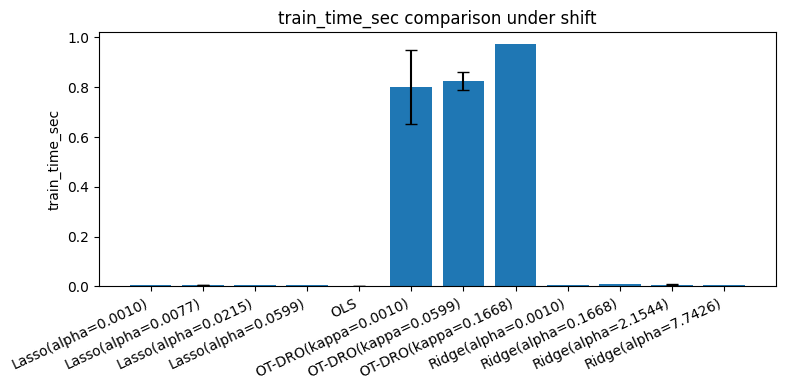

In [21]:
plot_metric_across_settings(summaries, metric="MAE")
plot_metric_across_settings(summaries, metric="RMSE")
plot_metric_across_settings(summaries, metric="train_time_sec")

# Interpretation of results

Expected trends:

- Under clean data, OLS and ridge may perform very well.
- Under noisy labels, ridge and OT-DRO may become more stable.
- Under outliers, OT-DRO should often improve because the fitting term uses absolute loss.
- Under distribution shift, OT-DRO may generalize better because it is derived from a worst-case nearby-distribution viewpoint.
- In training time, OLS is typically fastest, while OT-DRO may take longer because it is solved as a convex optimization problem.

# Conclusion

We implemented an OT-based robust linear regression model derived from distributionally robust optimization with an optimal transport cost.

For the quadratic transport penalty

$$
\psi(t)=\alpha t^2
$$

the Legendre transform is

$$
\psi^*(u)=\frac{u^2}{4\alpha}
$$

and the full OT-DRO problem reduces to

$$
\min_{\theta,b}
\frac{1}{n}\sum_{i=1}^n |y_i-(x_i^\top\theta+b)|
+
\kappa\|\theta\|_2
$$

where

$$
\kappa=\delta+\sqrt{\frac{\epsilon}{\alpha}}
$$

We compared this method against OLS, ridge, and lasso under clean data, noisy labels, outliers, and distribution shift, and evaluated both predictive performance and computational cost.